In [1]:
# ============================================
# PHASE 1 - DATA COLLECTION & EXPLORATION
# Bitcoin Volatility Risk Engine
# ============================================

import yfinance as yf            # downloads real market data
import pandas as pd              # handles tables/dataframes
import numpy as np               # mathematical operations
import matplotlib.pyplot as plt  # plotting charts
import seaborn as sns            # better looking charts
import warnings
warnings.filterwarnings('ignore')

# Make our charts look professional
plt.style.use('dark_background')
sns.set_palette("husl")

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [2]:
# ============================================
# CELL 2 - DOWNLOAD BITCOIN DATA
# ============================================

# Download Bitcoin price data from 2018 to today
btc = yf.download("BTC-USD", 
                   start="2018-01-01", 
                   end="2024-12-31",
                   progress=True)

# Show the shape - how many rows and columns
print(f"✅ Data downloaded successfully!")
print(f"📊 Total trading days: {len(btc)}")
print(f"📅 From: {btc.index[0].date()}")
print(f"📅 To:   {btc.index[-1].date()}")
print(f"\n🔍 First 5 rows:")
print(btc.head())

[*********************100%***********************]  1 of 1 completed

✅ Data downloaded successfully!
📊 Total trading days: 2556
📅 From: 2018-01-01
📅 To:   2024-12-30

🔍 First 5 rows:
Price              Close          High           Low          Open  \
Ticker           BTC-USD       BTC-USD       BTC-USD       BTC-USD   
Date                                                                 
2018-01-01  13657.200195  14112.200195  13154.700195  14112.200195   
2018-01-02  14982.099609  15444.599609  13163.599609  13625.000000   
2018-01-03  15201.000000  15572.799805  14844.500000  14978.200195   
2018-01-04  15599.200195  15739.700195  14522.200195  15270.700195   
2018-01-05  17429.500000  17705.199219  15202.799805  15477.200195   

Price            Volume  
Ticker          BTC-USD  
Date                     
2018-01-01  10291200000  
2018-01-02  16846600192  
2018-01-03  16871900160  
2018-01-04  21783199744  
2018-01-05  23840899072  


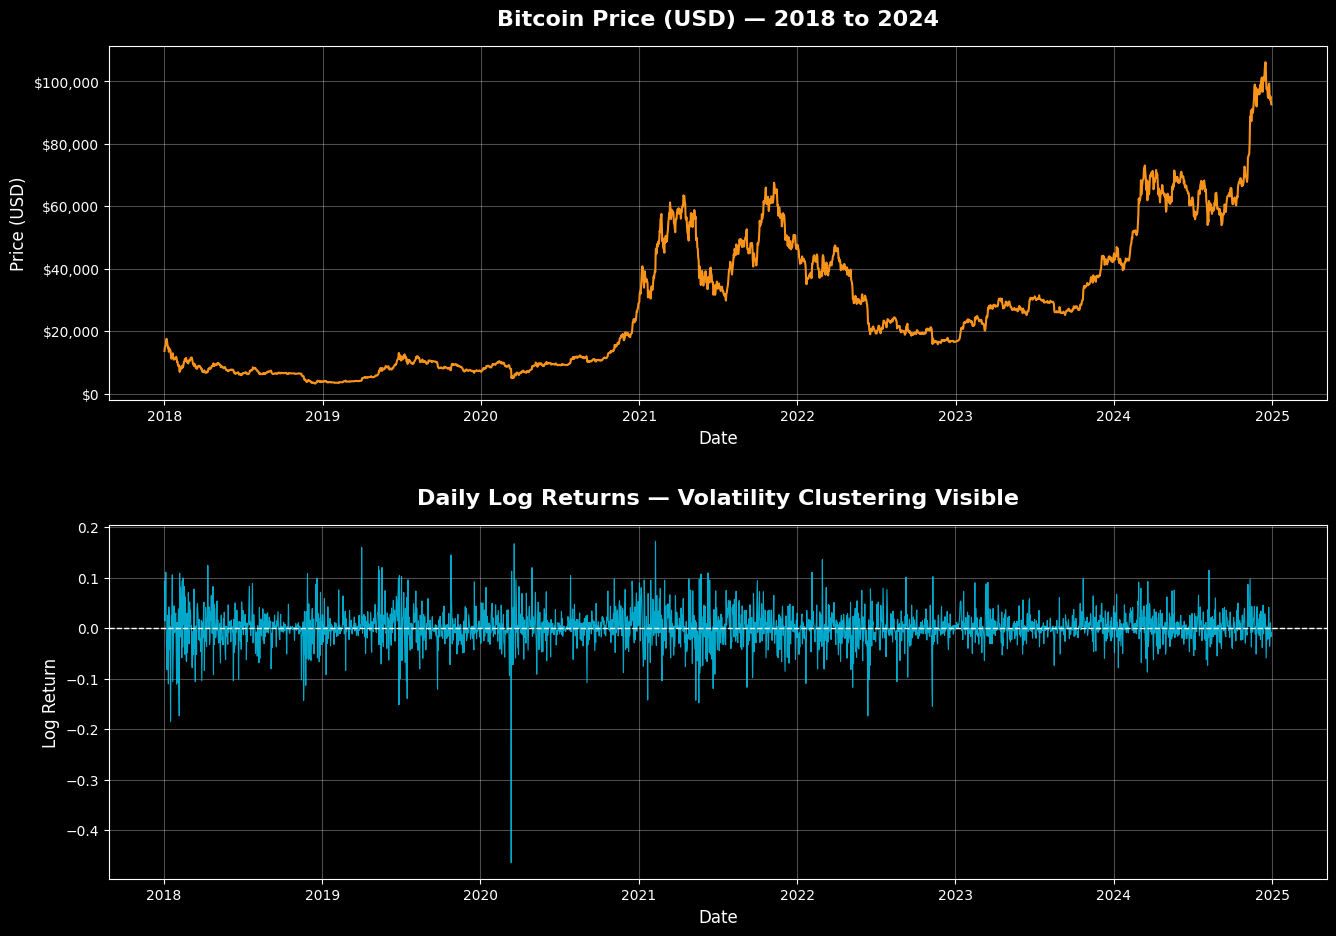


📈 Returns Statistics:
Mean daily return:  0.0007
Std of returns:     0.0357
Max single day gain: 0.1718
Max single day loss: -0.4647


In [3]:
# ============================================
# CELL 3 - CALCULATE RETURNS & PLOT
# ============================================

# Extract just the closing price
close_price = btc['Close']['BTC-USD']

# Calculate daily log returns
# Log return = ln(today's price / yesterday's price)
returns = np.log(close_price / close_price.shift(1))

# Remove the first row (it will be NaN because 
# there's no previous day to compare to)
returns = returns.dropna()

# ---- PLOT 1: Raw Bitcoin Price ----
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(close_price, color='#F7931A', linewidth=1.5)
axes[0].set_title('Bitcoin Price (USD) — 2018 to 2024', 
                   fontsize=16, fontweight='bold', pad=15)
axes[0].set_ylabel('Price (USD)', fontsize=12)
axes[0].set_xlabel('Date', fontsize=12)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0].grid(True, alpha=0.3)

# ---- PLOT 2: Daily Log Returns ----
axes[1].plot(returns, color='#00D4FF', linewidth=0.8, alpha=0.8)
axes[1].axhline(y=0, color='white', linewidth=1, linestyle='--')
axes[1].set_title('Daily Log Returns — Volatility Clustering Visible', 
                   fontsize=16, fontweight='bold', pad=15)
axes[1].set_ylabel('Log Return', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout(pad=3.0)
plt.savefig('../data/btc_price_returns.png', dpi=150, 
            bbox_inches='tight')
plt.show()

print(f"\n📈 Returns Statistics:")
print(f"Mean daily return:  {returns.mean():.4f}")
print(f"Std of returns:     {returns.std():.4f}")
print(f"Max single day gain: {returns.max():.4f}")
print(f"Max single day loss: {returns.min():.4f}")

In [4]:
# ============================================
# CELL 4 - STATIONARITY TESTING
# ============================================

from statsmodels.tsa.stattools import adfuller, kpss

def test_stationarity(series, name):
    """
    Run both ADF and KPSS tests on a series
    and print results in a clean readable way
    """
    print(f"{'='*50}")
    print(f"📊 Stationarity Tests for: {name}")
    print(f"{'='*50}")
    
    # ---- ADF TEST ----
    adf_result = adfuller(series, autolag='AIC')
    adf_pvalue = adf_result[1]
    
    print(f"\n🔬 ADF Test (Augmented Dickey-Fuller):")
    print(f"   Test Statistic : {adf_result[0]:.4f}")
    print(f"   P-value        : {adf_pvalue:.4f}")
    
    if adf_pvalue < 0.05:
        print(f"   Result         : ✅ STATIONARY (p < 0.05)")
    else:
        print(f"   Result         : ❌ NOT STATIONARY (p > 0.05)")
    
    # ---- KPSS TEST ----
    kpss_result = kpss(series, regression='c', nlags='auto')
    kpss_pvalue = kpss_result[1]
    
    print(f"\n🔬 KPSS Test:")
    print(f"   Test Statistic : {kpss_result[0]:.4f}")
    print(f"   P-value        : {kpss_pvalue:.4f}")
    
    if kpss_pvalue > 0.05:
        print(f"   Result         : ✅ STATIONARY (p > 0.05)")
    else:
        print(f"   Result         : ❌ NOT STATIONARY (p < 0.05)")
    
    # ---- FINAL CONCLUSION ----
    print(f"\n📌 Final Conclusion:")
    if adf_pvalue < 0.05 and kpss_pvalue > 0.05:
        print(f"   ✅ BOTH tests agree: {name} IS stationary!")
    elif adf_pvalue > 0.05 and kpss_pvalue < 0.05:
        print(f"   ❌ BOTH tests agree: {name} is NOT stationary!")
    else:
        print(f"   ⚠️  Tests disagree — needs further investigation")
    print()

# ---- TEST 1: Raw Bitcoin Price ----
test_stationarity(close_price.dropna(), "Raw Bitcoin Price")

# ---- TEST 2: Log Returns ----
test_stationarity(returns, "Log Returns")

📊 Stationarity Tests for: Raw Bitcoin Price

🔬 ADF Test (Augmented Dickey-Fuller):
   Test Statistic : -0.3379
   P-value        : 0.9200
   Result         : ❌ NOT STATIONARY (p > 0.05)

🔬 KPSS Test:
   Test Statistic : 4.9193
   P-value        : 0.0100
   Result         : ❌ NOT STATIONARY (p < 0.05)

📌 Final Conclusion:
   ❌ BOTH tests agree: Raw Bitcoin Price is NOT stationary!

📊 Stationarity Tests for: Log Returns

🔬 ADF Test (Augmented Dickey-Fuller):
   Test Statistic : -34.9058
   P-value        : 0.0000
   Result         : ✅ STATIONARY (p < 0.05)

🔬 KPSS Test:
   Test Statistic : 0.1834
   P-value        : 0.1000
   Result         : ✅ STATIONARY (p > 0.05)

📌 Final Conclusion:
   ✅ BOTH tests agree: Log Returns IS stationary!



C:\Users\hp\AppData\Local\Temp\ipykernel_8088\1051168447.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression='c', nlags='auto')
C:\Users\hp\AppData\Local\Temp\ipykernel_8088\1051168447.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, regression='c', nlags='auto')


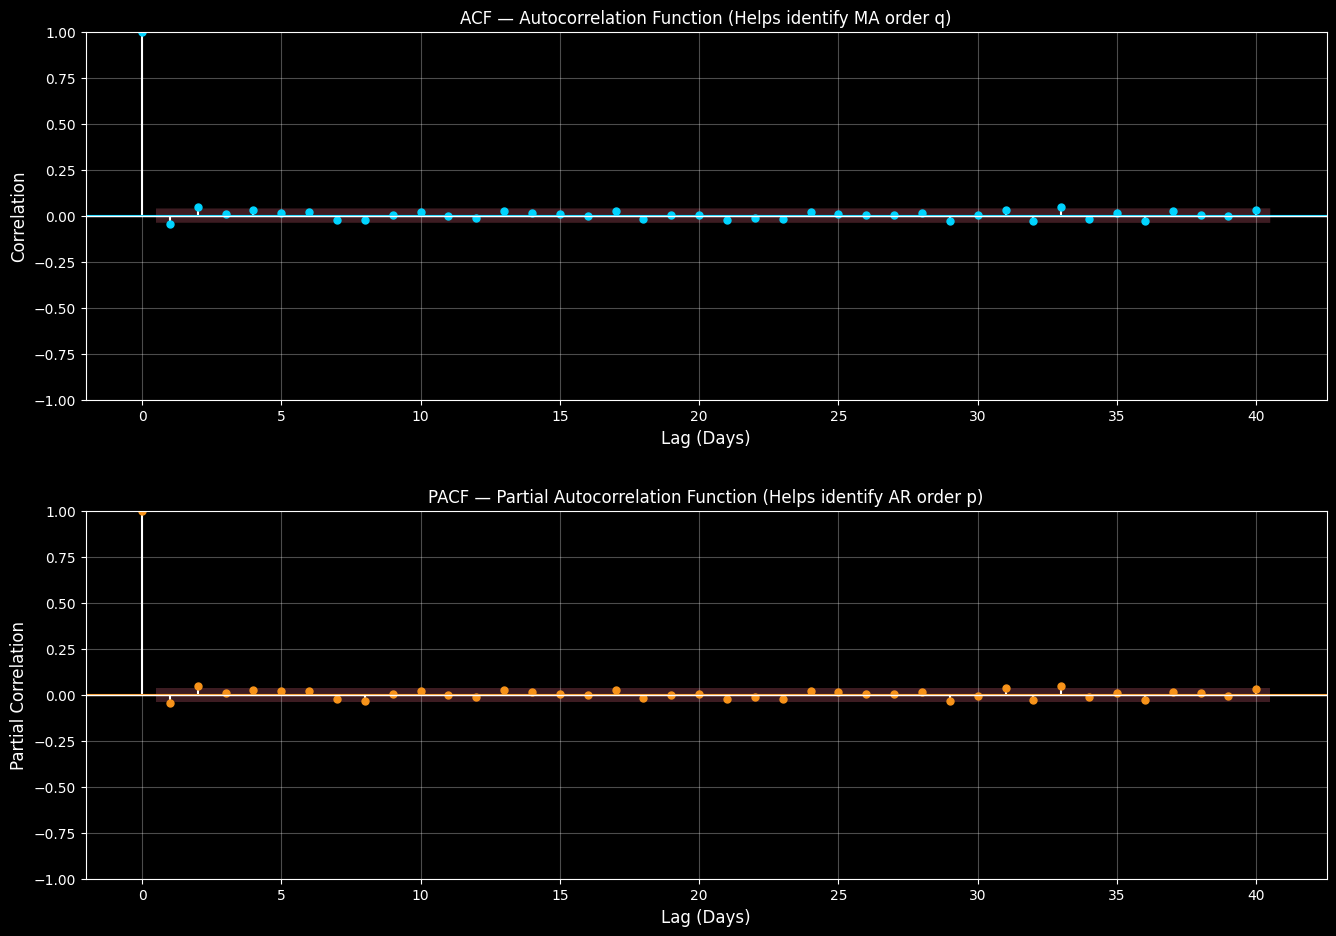

📌 How to read these plots:
   • Blue shaded area = confidence boundary
   • Bars OUTSIDE blue = significant lags
   • ACF sharp cutoff after lag q → MA(q)
   • PACF sharp cutoff after lag p → AR(p)


In [5]:
# ============================================
# CELL 5 - ACF & PACF ANALYSIS
# ============================================

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ---- PLOT 1: ACF ----
# Shows correlation between returns and past returns
# Helps identify MA(q) order
plot_acf(returns, 
         lags=40,          # look back 40 days
         ax=axes[0],
         color='#00D4FF',
         title='ACF — Autocorrelation Function (Helps identify MA order q)',
         alpha=0.05)       # 95% confidence interval

axes[0].set_xlabel('Lag (Days)', fontsize=12)
axes[0].set_ylabel('Correlation', fontsize=12)
axes[0].axhline(y=0, color='white', linewidth=1)
axes[0].grid(True, alpha=0.3)

# ---- PLOT 2: PACF ----
# Shows partial correlation after removing indirect effects
# Helps identify AR(p) order
plot_pacf(returns, 
          lags=40,         # look back 40 days
          ax=axes[1],
          color='#F7931A',
          title='PACF — Partial Autocorrelation Function (Helps identify AR order p)',
          alpha=0.05,      # 95% confidence interval
          method='ywm')

axes[1].set_xlabel('Lag (Days)', fontsize=12)
axes[1].set_ylabel('Partial Correlation', fontsize=12)
axes[1].axhline(y=0, color='white', linewidth=1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout(pad=3.0)
plt.savefig('../data/acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

print("📌 How to read these plots:")
print("   • Blue shaded area = confidence boundary")
print("   • Bars OUTSIDE blue = significant lags")
print("   • ACF sharp cutoff after lag q → MA(q)")
print("   • PACF sharp cutoff after lag p → AR(p)")

In [6]:
# ============================================
# CELL 6 - FIT ARIMA MODEL
# ============================================

from pmdarima import auto_arima

# ---- STEP 1: Split into Train & Test ----
# Train: 2018-2023 (model learns from this)
# Test:  2024 (we will predict this!)

train_returns = returns[returns.index.year < 2024]
test_returns  = returns[returns.index.year == 2024]

train_price = close_price[close_price.index.year < 2024]
test_price  = close_price[close_price.index.year == 2024]

print(f"📊 Data Split:")
print(f"   Training returns : {len(train_returns)} days")
print(f"   Testing returns  : {len(test_returns)} days")
print(f"   Training from    : {train_returns.index[0].date()}")
print(f"   Training to      : {train_returns.index[-1].date()}")
print(f"   Testing from     : {test_returns.index[0].date()}")
print(f"   Testing to       : {test_returns.index[-1].date()}")

# ---- STEP 2: Fit auto_arima ----
print(f"\n🔍 Finding best ARIMA model...")

arima_model = auto_arima(
    train_returns,
    start_p=0, max_p=3,   # test AR orders 0 to 3
    start_q=0, max_q=3,   # test MA orders 0 to 3
    d=0,                   # returns already stationary
    seasonal=False,        # no seasonality in daily returns
    information_criterion='aic',  # use AIC to select
    stepwise=True,         # faster search
    suppress_warnings=True,
    error_action='ignore',
    trace=True             # show progress
)

print(f"\n✅ Best model found!")
print(f"   Selected order: ARIMA{arima_model.order}")
print(f"   AIC Score: {arima_model.aic():.4f}")

📊 Data Split:
   Training returns : 2190 days
   Testing returns  : 365 days
   Training from    : 2018-01-02
   Training to      : 2023-12-31
   Testing from     : 2024-01-01
   Testing to       : 2024-12-30

🔍 Finding best ARIMA model...
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-8245.558, Time=0.41 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-8247.894, Time=0.27 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-8247.523, Time=0.33 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-8250.390, Time=0.28 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=-8248.913, Time=0.42 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-8250.559, Time=0.84 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-8249.017, Time=0.53 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=-8246.954, Time=0.23 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-8246.391, Time=0.44 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-8249.702, Time=0.18 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=-8247

In [7]:
# ============================================
# CELL 7 - ARIMA SUMMARY & PREDICTIONS
# ============================================

# ---- STEP 1: Print Full Model Summary ----
print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2190
Model:               SARIMAX(2, 0, 1)   Log Likelihood                4129.280
Date:                Thu, 14 May 2026   AIC                          -8250.559
Time:                        22:54:18   BIC                          -8227.793
Sample:                    01-02-2018   HQIC                         -8242.238
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5593      0.199      2.807      0.005       0.169       0.950
ar.L2          0.0709      0.017      4.124      0.000       0.037       0.105
ma.L1         -0.6036      0.200     -3.016      0.0

✅ Predicted 365 days of returns
📌 Last known price (Dec 31 2023): $42,265.19


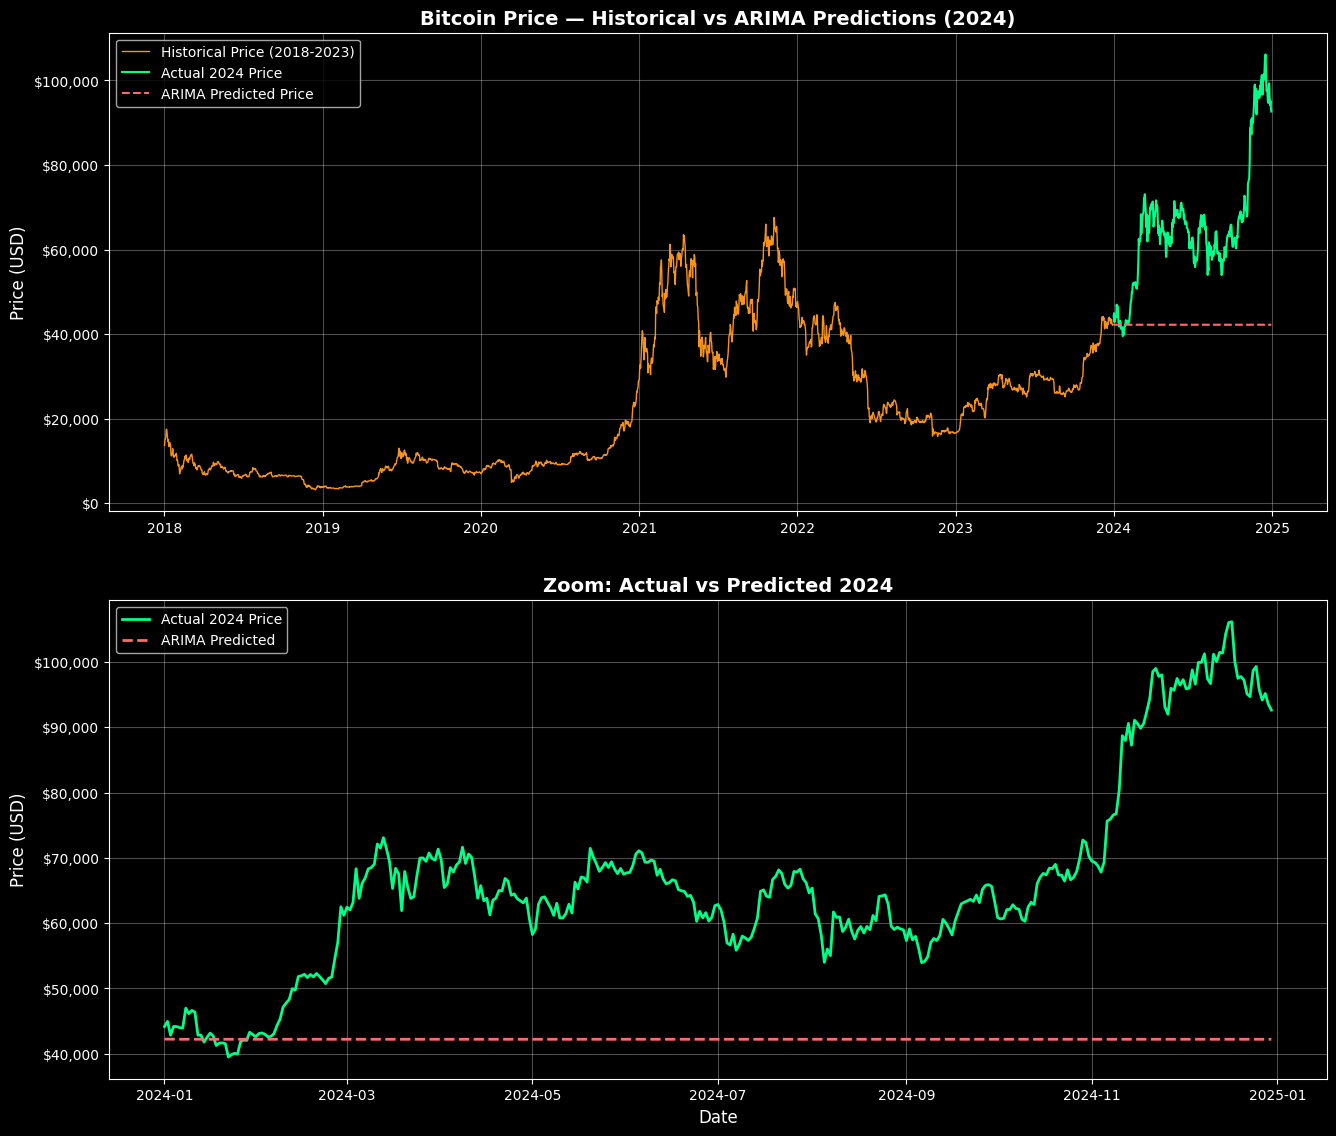


📊 ARIMA Model Accuracy on 2024 Data:
   MAE  : $23,745.73
   RMSE : $27,819.19
   MAPE : 33.06%


In [8]:
# ============================================
# CELL 8 - ARIMA PREDICTIONS & EVALUATION
# ============================================

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ---- STEP 1: Predict 2024 Returns ----
n_forecast = len(test_returns)  # 365 days

predicted_returns, conf_int = arima_model.predict(
    n_periods=n_forecast,
    return_conf_int=True,
    alpha=0.05  # 95% confidence interval
)

print(f"✅ Predicted {n_forecast} days of returns")

# ---- STEP 2: Convert Returns to Prices ----
# Start from last known price (Dec 31 2023)
last_known_price = train_price.iloc[-1]
print(f"📌 Last known price (Dec 31 2023): ${last_known_price:,.2f}")

# Build predicted prices day by day
predicted_prices = [last_known_price]
for r in predicted_returns:
    next_price = predicted_prices[-1] * np.exp(r)
    predicted_prices.append(next_price)

# Remove first element (it's the last known price)
predicted_prices = predicted_prices[1:]
predicted_prices = pd.Series(
    predicted_prices, 
    index=test_price.index
)

# ---- STEP 3: Plot Predictions vs Reality ----
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1 — Full picture (train + test + prediction)
axes[0].plot(train_price.index, train_price, 
             color='#F7931A', linewidth=1, 
             label='Historical Price (2018-2023)')
axes[0].plot(test_price.index, test_price, 
             color='#00FF88', linewidth=1.5, 
             label='Actual 2024 Price')
axes[0].plot(predicted_prices.index, predicted_prices, 
             color='#FF6B6B', linewidth=1.5, 
             linestyle='--', label='ARIMA Predicted Price')
axes[0].set_title('Bitcoin Price — Historical vs ARIMA Predictions (2024)', 
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (USD)', fontsize=12)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2 — Zoom into 2024 only
axes[1].plot(test_price.index, test_price, 
             color='#00FF88', linewidth=2, 
             label='Actual 2024 Price')
axes[1].plot(predicted_prices.index, predicted_prices, 
             color='#FF6B6B', linewidth=2, 
             linestyle='--', label='ARIMA Predicted')
axes[1].set_title('Zoom: Actual vs Predicted 2024', 
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('Price (USD)', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout(pad=3.0)
plt.savefig('../data/arima_predictions.png', 
            dpi=150, bbox_inches='tight')
plt.show()

# ---- STEP 4: Measure Accuracy ----
mae  = mean_absolute_error(test_price, predicted_prices)
rmse = np.sqrt(mean_squared_error(test_price, predicted_prices))
mape = np.mean(np.abs((test_price - predicted_prices) / test_price)) * 100

print(f"\n📊 ARIMA Model Accuracy on 2024 Data:")
print(f"   MAE  : ${mae:,.2f}")
print(f"   RMSE : ${rmse:,.2f}")
print(f"   MAPE : {mape:.2f}%")

In [9]:
# ============================================
# CELL 9 - GARCH MODELLING
# ============================================

from arch import arch_model

# ---- STEP 1: Get ARIMA Residuals ----
arima_residuals = pd.Series(
    arima_model.resid(),
    index=train_returns.index
)

print(f"✅ ARIMA Residuals extracted!")
print(f"   Total residuals : {len(arima_residuals)}")
print(f"   Mean            : {arima_residuals.mean():.6f}")
print(f"   Std             : {arima_residuals.std():.6f}")

# ---- STEP 2: Fit GARCH(1,1) Model ----
print(f"\n🔍 Fitting GARCH(1,1) model...")

# Scale residuals by 100 for numerical stability
# (standard practice in finance)
garch = arch_model(
    arima_residuals * 100,
    vol='Garch',      # GARCH volatility model
    p=1,              # 1 past variance
    q=1,              # 1 past shock
    dist='normal',    # normal distribution
    mean='Zero'       # residuals mean = 0
)

garch_model = garch.fit(
    disp='off',       # don't show iteration details
    show_warning=False
)

print(f"\n✅ GARCH(1,1) fitted successfully!")
print(f"\n📊 GARCH Model Summary:")
print(garch_model.summary())

✅ ARIMA Residuals extracted!
   Total residuals : 2190
   Mean            : 0.000481
   Std             : 0.036725

🔍 Fitting GARCH(1,1) model...

✅ GARCH(1,1) fitted successfully!

📊 GARCH Model Summary:
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -5830.16
Distribution:                  Normal   AIC:                           11666.3
Method:            Maximum Likelihood   BIC:                           11683.4
                                        No. Observations:                 2190
Date:                Thu, May 14 2026   Df Residuals:                     2190
Time:                        22:54:20   Df Model:                            0
                              Volatility Model                             
        

In [10]:
# ============================================
# CELL 10 - GARCH PARAMETERS
# ============================================

params = garch_model.params
print("📊 GARCH(1,1) Parameters:")
print(f"   omega   = {params['omega']:.6f}")
print(f"   alpha[1]= {params['alpha[1]']:.6f}")
print(f"   beta[1] = {params['beta[1]']:.6f}")
print(f"\n   alpha + beta = {params['alpha[1]'] + params['beta[1]']:.6f}")
print(f"   (Must be < 1 for stability)")

# Check stability
if params['alpha[1]'] + params['beta[1]'] < 1:
    print(f"   ✅ Model is STABLE!")
else:
    print(f"   ❌ Model is UNSTABLE!")

📊 GARCH(1,1) Parameters:
   omega   = 0.723154
   alpha[1]= 0.095321
   beta[1] = 0.856632

   alpha + beta = 0.951954
   (Must be < 1 for stability)
   ✅ Model is STABLE!


✅ Conditional volatility extracted!
   Average daily volatility: 0.0359
   Max daily volatility:     0.1469
   Min daily volatility:     0.0232


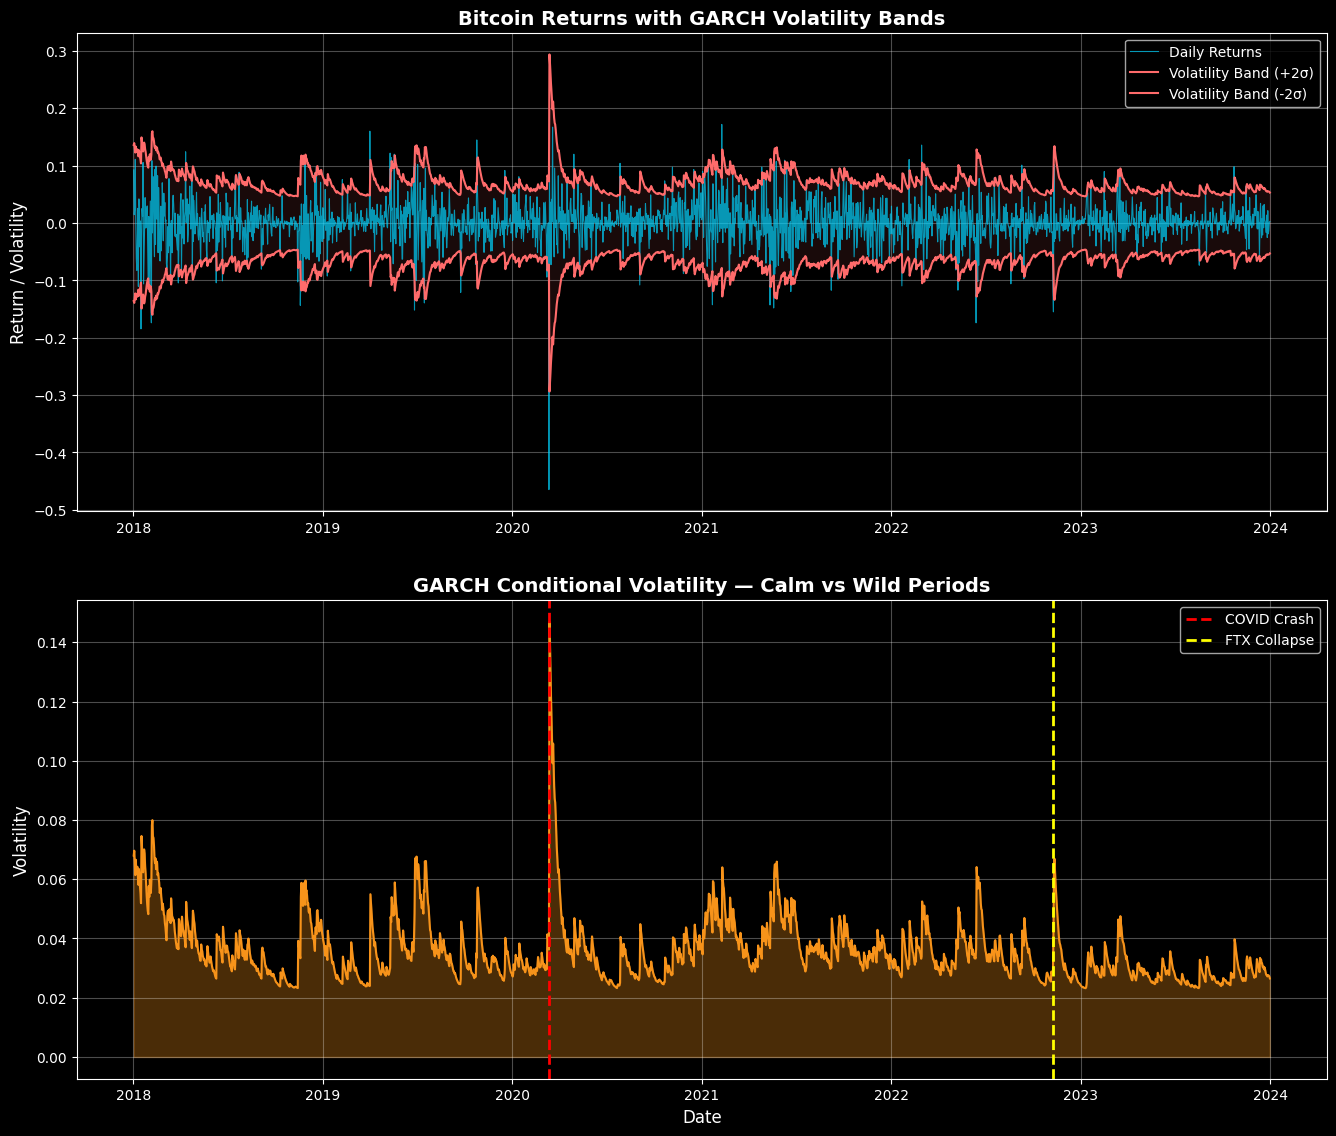

In [11]:
# ============================================
# CELL 11 - VOLATILITY FORECAST PLOT
# ============================================

# ---- STEP 1: Get Conditional Volatility ----
# This is GARCH's estimate of volatility 
# for each day in training period
conditional_vol = garch_model.conditional_volatility / 100

print(f"✅ Conditional volatility extracted!")
print(f"   Average daily volatility: {conditional_vol.mean():.4f}")
print(f"   Max daily volatility:     {conditional_vol.max():.4f}")
print(f"   Min daily volatility:     {conditional_vol.min():.4f}")

# ---- STEP 2: Plot Volatility Over Time ----
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1 — Returns with volatility bands
axes[0].plot(train_returns.index, train_returns, 
             color='#00D4FF', linewidth=0.8, 
             alpha=0.7, label='Daily Returns')
axes[0].plot(train_returns.index, conditional_vol * 2, 
             color='#FF6B6B', linewidth=1.5, 
             label='Volatility Band (+2σ)')
axes[0].plot(train_returns.index, -conditional_vol * 2, 
             color='#FF6B6B', linewidth=1.5, 
             label='Volatility Band (-2σ)')
axes[0].fill_between(train_returns.index, 
                      conditional_vol * 2, 
                      -conditional_vol * 2,
                      color='#FF6B6B', alpha=0.1)
axes[0].set_title('Bitcoin Returns with GARCH Volatility Bands', 
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('Return / Volatility', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2 — Conditional Volatility Over Time
axes[1].plot(train_returns.index, conditional_vol, 
             color='#F7931A', linewidth=1.5)
axes[1].fill_between(train_returns.index, 
                      0, conditional_vol,
                      color='#F7931A', alpha=0.3)
axes[1].set_title('GARCH Conditional Volatility — Calm vs Wild Periods', 
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('Volatility', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Mark important events
axes[1].axvline(x=pd.Timestamp('2020-03-12'), 
                color='red', linewidth=2, 
                linestyle='--', label='COVID Crash')
axes[1].axvline(x=pd.Timestamp('2022-11-08'), 
                color='yellow', linewidth=2, 
                linestyle='--', label='FTX Collapse')
axes[1].legend(fontsize=10)

plt.tight_layout(pad=3.0)
plt.savefig('../data/garch_volatility.png', 
            dpi=150, bbox_inches='tight')
plt.show()

💰 Investment Amount : £10,000
📊 Confidence Level  : 95.0%
📐 Z-score           : -1.6449

📊 METHOD 1 — Historical VaR
   5th percentile return : -0.0590 (-5.90%)
   VaR (£10,000)        : £589.96

   Meaning: On 95% of days you will NOT
   lose more than £589.96 on a £10,000 investment

📊 METHOD 2 — GARCH VaR (Dynamic)
   Average GARCH VaR : -0.0591 (-5.91%)
   Max GARCH VaR     : -0.2417 (-24.17%)
   Min GARCH VaR     : -0.0382 (-3.82%)

   In £ terms (£10,000 investment):
   Average daily VaR : £590.97
   Worst day VaR     : £2,416.60
   Best day VaR      : £382.27


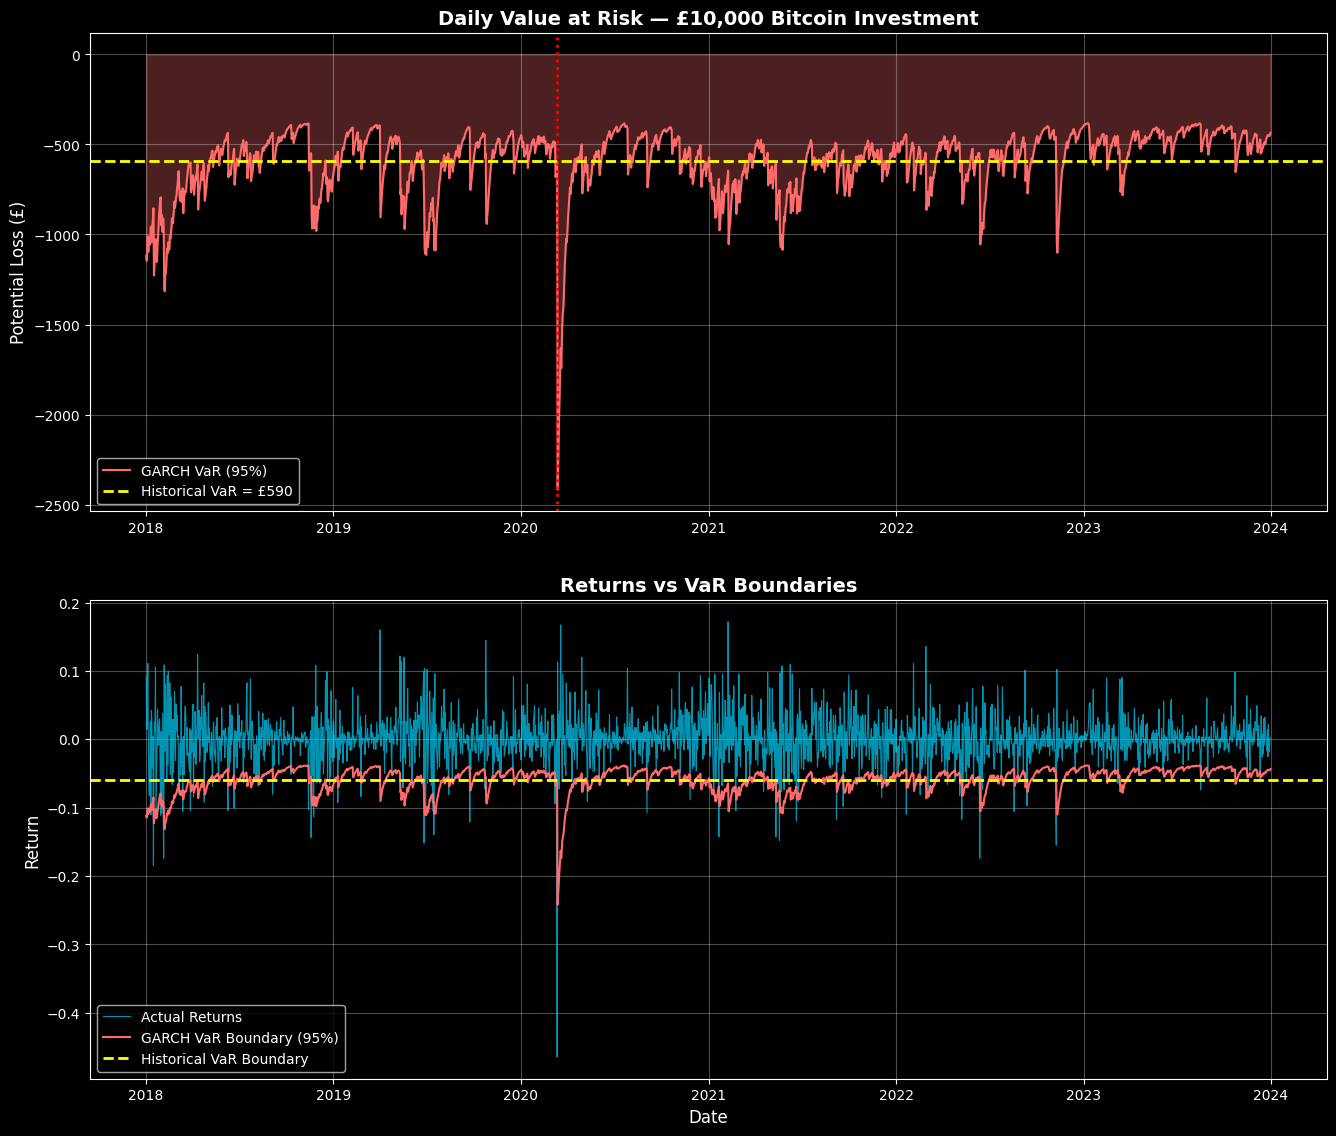

In [12]:
# ============================================
# CELL 12 - VALUE AT RISK (VaR)
# ============================================

from scipy import stats

# ---- SETUP ----
investment = 10000  # £10,000 investment
confidence = 0.95   # 95% confidence level
z_score = stats.norm.ppf(1 - confidence)  # = -1.645

print(f"💰 Investment Amount : £{investment:,}")
print(f"📊 Confidence Level  : {confidence*100}%")
print(f"📐 Z-score           : {z_score:.4f}")

# ---- METHOD 1: Historical VaR ----
# Simply look at worst 5% of actual returns
historical_var = np.percentile(train_returns, 5)

print(f"\n{'='*50}")
print(f"📊 METHOD 1 — Historical VaR")
print(f"{'='*50}")
print(f"   5th percentile return : {historical_var:.4f} ({historical_var*100:.2f}%)")
print(f"   VaR (£{investment:,})        : £{abs(historical_var * investment):,.2f}")
print(f"\n   Meaning: On 95% of days you will NOT")
print(f"   lose more than £{abs(historical_var * investment):,.2f} on a £{investment:,} investment")

# ---- METHOD 2: GARCH VaR ----
# Uses conditional volatility — changes every day!
garch_var = z_score * conditional_vol

print(f"\n{'='*50}")
print(f"📊 METHOD 2 — GARCH VaR (Dynamic)")
print(f"{'='*50}")
print(f"   Average GARCH VaR : {garch_var.mean():.4f} ({garch_var.mean()*100:.2f}%)")
print(f"   Max GARCH VaR     : {garch_var.min():.4f} ({garch_var.min()*100:.2f}%)")
print(f"   Min GARCH VaR     : {garch_var.max():.4f} ({garch_var.max()*100:.2f}%)")

print(f"\n   In £ terms (£{investment:,} investment):")
print(f"   Average daily VaR : £{abs(garch_var.mean() * investment):,.2f}")
print(f"   Worst day VaR     : £{abs(garch_var.min() * investment):,.2f}")
print(f"   Best day VaR      : £{abs(garch_var.max() * investment):,.2f}")

# ---- PLOT VaR Over Time ----
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1 — GARCH VaR over time
axes[0].plot(train_returns.index, garch_var * investment,
             color='#FF6B6B', linewidth=1.5,
             label='GARCH VaR (95%)')
axes[0].axhline(y=historical_var * investment,
                color='yellow', linewidth=2,
                linestyle='--',
                label=f'Historical VaR = £{abs(historical_var * investment):,.0f}')
axes[0].fill_between(train_returns.index,
                      garch_var * investment, 0,
                      color='#FF6B6B', alpha=0.3)
axes[0].set_title(f'Daily Value at Risk — £{investment:,} Bitcoin Investment',
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('Potential Loss (£)', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Mark COVID crash
axes[0].axvline(x=pd.Timestamp('2020-03-12'),
                color='red', linewidth=2,
                linestyle=':', label='COVID Crash')

# Plot 2 — Returns vs VaR boundaries
axes[1].plot(train_returns.index, train_returns,
             color='#00D4FF', linewidth=0.8,
             alpha=0.7, label='Actual Returns')
axes[1].plot(train_returns.index, garch_var,
             color='#FF6B6B', linewidth=1.5,
             label='GARCH VaR Boundary (95%)')
axes[1].axhline(y=historical_var,
                color='yellow', linewidth=2,
                linestyle='--',
                label='Historical VaR Boundary')
axes[1].set_title('Returns vs VaR Boundaries',
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('Return', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout(pad=3.0)
plt.savefig('../data/value_at_risk.png',
            dpi=150, bbox_inches='tight')
plt.show()

✅ GARCH volatility forecasted for 2024
   Forecast days     : 365
   Average volatility: 0.0381
   Max volatility    : 0.0388
   Min volatility    : 0.0260

💰 2024 VaR Estimates (£10,000 investment):
   Average daily VaR : £627.21
   Worst day VaR     : £638.13
   Best day VaR      : £427.52

📊 Backtesting Results:
   Total days tested    : 365
   Expected breaches    : 18 (5%)
   Actual breaches      : 5
   Breach rate          : 1.37%
   Result: ✅ Model is GOOD!
   VaR was conservative enough!


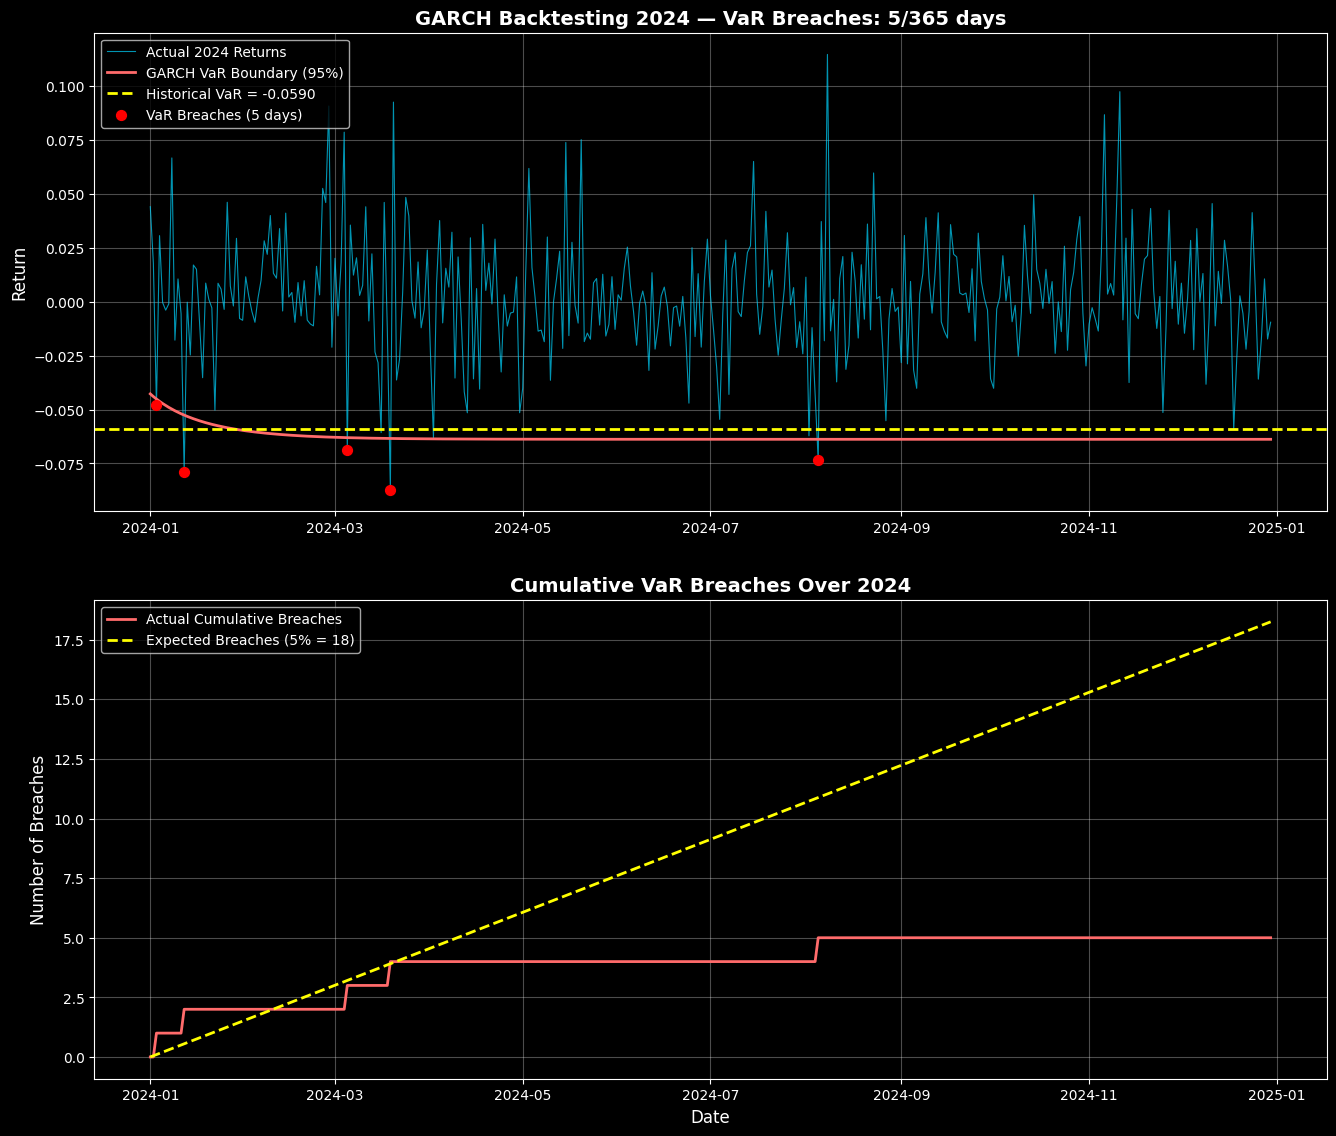

In [13]:
# ============================================
# CELL 13 - GARCH BACKTESTING ON 2024
# ============================================

# ---- STEP 1: Forecast 2024 Volatility ----
# Use trained GARCH model to forecast 2024
n_forecast = len(test_returns)  # 365 days

garch_forecast = garch_model.forecast(
    horizon=n_forecast,
    reindex=False
)

# Extract forecasted variance and convert to volatility
forecast_variance = garch_forecast.variance.values[-1]
forecast_volatility = np.sqrt(forecast_variance) / 100

print(f"✅ GARCH volatility forecasted for 2024")
print(f"   Forecast days     : {n_forecast}")
print(f"   Average volatility: {forecast_volatility.mean():.4f}")
print(f"   Max volatility    : {forecast_volatility.max():.4f}")
print(f"   Min volatility    : {forecast_volatility.min():.4f}")

# ---- STEP 2: Calculate 2024 VaR ----
forecast_var = z_score * forecast_volatility

print(f"\n💰 2024 VaR Estimates (£{investment:,} investment):")
print(f"   Average daily VaR : £{abs(forecast_var.mean() * investment):,.2f}")
print(f"   Worst day VaR     : £{abs(forecast_var.min() * investment):,.2f}")
print(f"   Best day VaR      : £{abs(forecast_var.max() * investment):,.2f}")

# ---- STEP 3: Count VaR Breaches ----
# Breach = actual loss exceeded predicted VaR
actual_losses = test_returns.values
breaches = actual_losses < forecast_var

n_breaches = breaches.sum()
breach_rate = n_breaches / n_forecast * 100
expected_breaches = n_forecast * 0.05

print(f"\n📊 Backtesting Results:")
print(f"   Total days tested    : {n_forecast}")
print(f"   Expected breaches    : {expected_breaches:.0f} (5%)")
print(f"   Actual breaches      : {n_breaches}")
print(f"   Breach rate          : {breach_rate:.2f}%")

if breach_rate <= 5:
    print(f"   Result: ✅ Model is GOOD!")
    print(f"   VaR was conservative enough!")
else:
    print(f"   Result: ⚠️ Model UNDERESTIMATES risk!")
    print(f"   More breaches than expected!")

# ---- STEP 4: Plot Backtesting Results ----
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Create date index for forecast
forecast_dates = test_returns.index

# Plot 1 — Forecasted VaR vs Actual Returns
axes[0].plot(forecast_dates, test_returns.values,
             color='#00D4FF', linewidth=0.8,
             alpha=0.7, label='Actual 2024 Returns')
axes[0].plot(forecast_dates, forecast_var,
             color='#FF6B6B', linewidth=2,
             label='GARCH VaR Boundary (95%)')
axes[0].axhline(y=historical_var,
                color='yellow', linewidth=2,
                linestyle='--',
                label=f'Historical VaR = {historical_var:.4f}')

# Mark breaches
breach_dates = forecast_dates[breaches]
breach_values = actual_losses[breaches]
axes[0].scatter(breach_dates, breach_values,
                color='red', s=50, zorder=5,
                label=f'VaR Breaches ({n_breaches} days)')

axes[0].set_title(f'GARCH Backtesting 2024 — VaR Breaches: {n_breaches}/{n_forecast} days',
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('Return', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2 — Cumulative breaches over time
cumulative_breaches = np.cumsum(breaches)
expected_cumulative = np.linspace(0, expected_breaches, n_forecast)

axes[1].plot(forecast_dates, cumulative_breaches,
             color='#FF6B6B', linewidth=2,
             label='Actual Cumulative Breaches')
axes[1].plot(forecast_dates, expected_cumulative,
             color='yellow', linewidth=2,
             linestyle='--',
             label=f'Expected Breaches (5% = {expected_breaches:.0f})')
axes[1].set_title('Cumulative VaR Breaches Over 2024',
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Breaches', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout(pad=3.0)
plt.savefig('../data/garch_backtesting.png',
            dpi=150, bbox_inches='tight')
plt.show()

🔮 2025 GARCH Volatility Forecast
   Forecast days        : 365
   Average volatility   : 0.0381 (3.81% per day)
   Max volatility       : 0.0388 (3.88%)
   Min volatility       : 0.0260 (2.60%)

💰 2025 VaR Estimates (£10,000 investment):
   Average daily VaR    : £627.21
   Worst day VaR        : £638.13
   Best day VaR         : £427.52


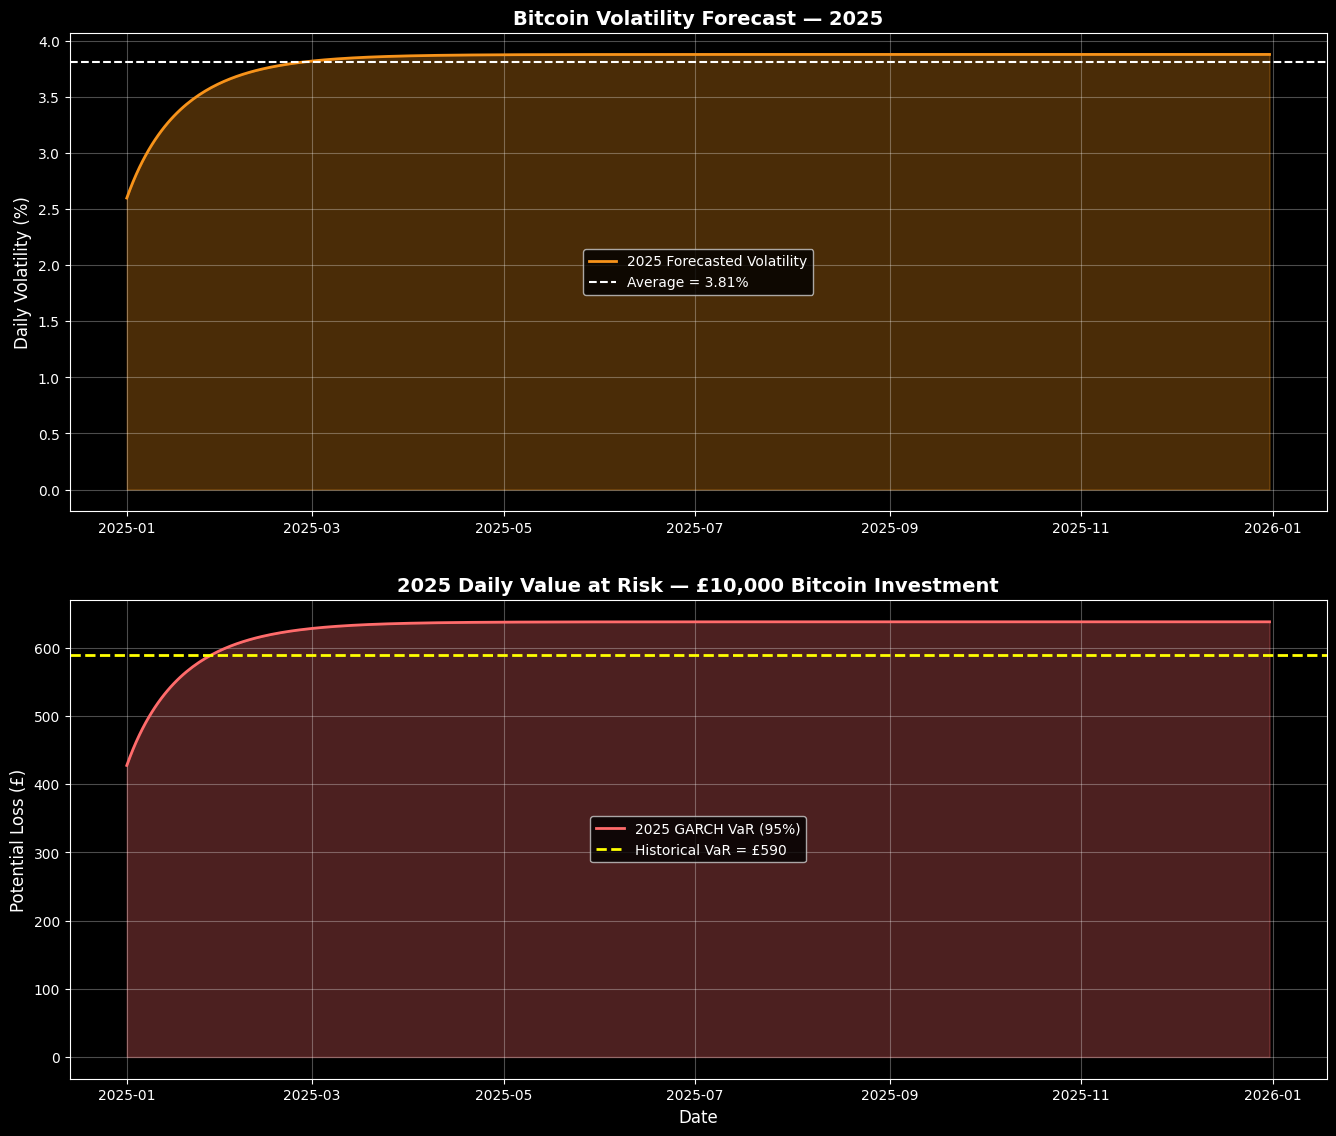

In [14]:
# Cell 14 — 2025 GARCH Volatility Forecast & VaR

# Step 1: Forecast 365 days into 2025
n_forecast_2025 = 365

garch_forecast_2025 = garch_model.forecast(horizon=n_forecast_2025, reindex=False)
forecast_variance_2025 = garch_forecast_2025.variance.values[-1]
forecast_volatility_2025 = np.sqrt(forecast_variance_2025) / 100

# Step 2: Create date index for 2025
forecast_dates_2025 = pd.date_range(start='2025-01-01', periods=n_forecast_2025, freq='D')

# Step 3: Calculate VaR for 2025
forecast_var_2025 = z_score * forecast_volatility_2025

# Step 4: Print summary
print("=" * 50)
print("🔮 2025 GARCH Volatility Forecast")
print("=" * 50)
print(f"   Forecast days        : {n_forecast_2025}")
print(f"   Average volatility   : {forecast_volatility_2025.mean():.4f} ({forecast_volatility_2025.mean()*100:.2f}% per day)")
print(f"   Max volatility       : {forecast_volatility_2025.max():.4f} ({forecast_volatility_2025.max()*100:.2f}%)")
print(f"   Min volatility       : {forecast_volatility_2025.min():.4f} ({forecast_volatility_2025.min()*100:.2f}%)")

print(f"\n💰 2025 VaR Estimates (£{investment:,} investment):")
print(f"   Average daily VaR    : £{abs(forecast_var_2025.mean() * investment):,.2f}")
print(f"   Worst day VaR        : £{abs(forecast_var_2025.min() * investment):,.2f}")
print(f"   Best day VaR         : £{abs(forecast_var_2025.max() * investment):,.2f}")

# Step 5: Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1 — Volatility forecast
axes[0].plot(forecast_dates_2025, forecast_volatility_2025 * 100,
             color='#F7931A', linewidth=2, label='2025 Forecasted Volatility')
axes[0].fill_between(forecast_dates_2025, 0, forecast_volatility_2025 * 100,
                     color='#F7931A', alpha=0.3)
axes[0].axhline(y=forecast_volatility_2025.mean() * 100,
                color='white', linewidth=1.5, linestyle='--',
                label=f'Average = {forecast_volatility_2025.mean()*100:.2f}%')
axes[0].set_title('Bitcoin Volatility Forecast — 2025', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Daily Volatility (%)', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2 — VaR forecast in £
axes[1].plot(forecast_dates_2025, abs(forecast_var_2025 * investment),
             color='#FF6B6B', linewidth=2, label='2025 GARCH VaR (95%)')
axes[1].fill_between(forecast_dates_2025, 0, abs(forecast_var_2025 * investment),
                     color='#FF6B6B', alpha=0.3)
axes[1].axhline(y=abs(historical_var * investment),
                color='yellow', linewidth=2, linestyle='--',
                label=f'Historical VaR = £{abs(historical_var * investment):,.0f}')
axes[1].set_title(f'2025 Daily Value at Risk — £{investment:,} Bitcoin Investment', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Potential Loss (£)', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout(pad=3.0)
plt.savefig('../data/2025_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Cell 15 — Download Real 2025 BTC Data

btc_2025 = yf.download("BTC-USD", start="2025-01-01", end="2025-12-31", progress=True)

close_2025 = btc_2025['Close']['BTC-USD']
returns_2025 = np.log(close_2025 / close_2025.shift(1)).dropna()

print(f"✅ 2025 data downloaded!")
print(f"📊 Total days: {len(returns_2025)}")
print(f"📅 From: {returns_2025.index[0].date()}")
print(f"📅 To:   {returns_2025.index[-1].date()}")
print(f"\n📈 2025 Returns Statistics:")
print(f"   Mean daily return : {returns_2025.mean():.4f}")
print(f"   Std of returns    : {returns_2025.std():.4f}")
print(f"   Max single day gain: {returns_2025.max():.4f}")
print(f"   Max single day loss: {returns_2025.min():.4f}")

[*********************100%***********************]  1 of 1 completed

✅ 2025 data downloaded!
📊 Total days: 363
📅 From: 2025-01-02
📅 To:   2025-12-30

📈 2025 Returns Statistics:
   Mean daily return : -0.0002
   Std of returns    : 0.0220
   Max single day gain: 0.0912
   Max single day loss: -0.0908


📊 2025 Backtesting Results
   Total days tested    : 363
   Expected breaches    : 18 (5%)
   Actual breaches      : 5
   Breach rate          : 1.38%
   Result: ✅ Model is GOOD! Conservative and protective!


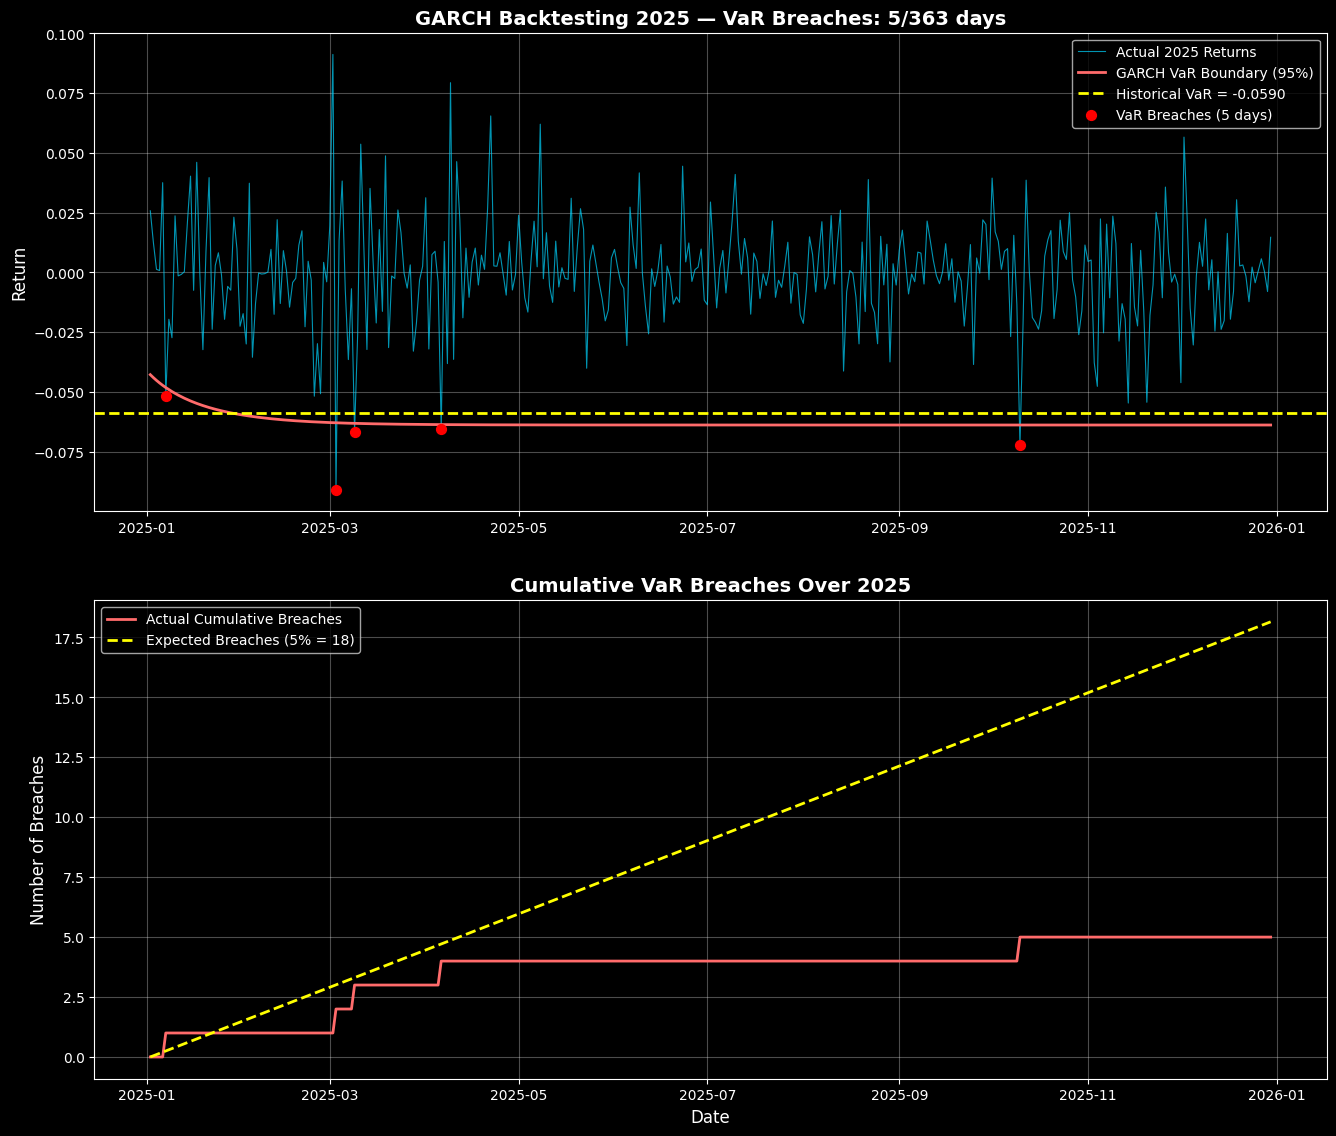

In [16]:
# Cell 16 — 2025 Backtesting (Predicted vs Reality)

n_forecast_2025 = len(returns_2025)

# Step 1: Recalculate forecast for exact number of days
garch_forecast_2025 = garch_model.forecast(horizon=n_forecast_2025, reindex=False)
forecast_variance_2025 = garch_forecast_2025.variance.values[-1]
forecast_volatility_2025 = np.sqrt(forecast_variance_2025) / 100

# Step 2: Align dates
forecast_dates_2025 = returns_2025.index
forecast_var_2025 = z_score * forecast_volatility_2025

# Step 3: Count breaches
actual_losses_2025 = returns_2025.values
breaches_2025 = actual_losses_2025 < forecast_var_2025
n_breaches_2025 = breaches_2025.sum()
breach_rate_2025 = n_breaches_2025 / n_forecast_2025 * 100
expected_breaches_2025 = n_forecast_2025 * 0.05

print("=" * 50)
print("📊 2025 Backtesting Results")
print("=" * 50)
print(f"   Total days tested    : {n_forecast_2025}")
print(f"   Expected breaches    : {expected_breaches_2025:.0f} (5%)")
print(f"   Actual breaches      : {n_breaches_2025}")
print(f"   Breach rate          : {breach_rate_2025:.2f}%")

if breach_rate_2025 <= 5:
    print(f"   Result: ✅ Model is GOOD! Conservative and protective!")
else:
    print(f"   Result: ⚠️ Model UNDERESTIMATES risk!")

# Step 4: Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1 — Returns vs VaR boundary
axes[0].plot(forecast_dates_2025, actual_losses_2025, 
             color='#00D4FF', linewidth=0.8, alpha=0.7, label='Actual 2025 Returns')
axes[0].plot(forecast_dates_2025, forecast_var_2025, 
             color='#FF6B6B', linewidth=2, label='GARCH VaR Boundary (95%)')
axes[0].axhline(y=historical_var, color='yellow', linewidth=2, 
                linestyle='--', label=f'Historical VaR = {historical_var:.4f}')
breach_dates_2025 = forecast_dates_2025[breaches_2025]
breach_values_2025 = actual_losses_2025[breaches_2025]
axes[0].scatter(breach_dates_2025, breach_values_2025, 
                color='red', s=50, zorder=5, label=f'VaR Breaches ({n_breaches_2025} days)')
axes[0].set_title(f'GARCH Backtesting 2025 — VaR Breaches: {n_breaches_2025}/{n_forecast_2025} days', 
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Return', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2 — Cumulative breaches
cumulative_breaches_2025 = np.cumsum(breaches_2025)
expected_cumulative_2025 = np.linspace(0, expected_breaches_2025, n_forecast_2025)
axes[1].plot(forecast_dates_2025, cumulative_breaches_2025, 
             color='#FF6B6B', linewidth=2, label='Actual Cumulative Breaches')
axes[1].plot(forecast_dates_2025, expected_cumulative_2025, 
             color='yellow', linewidth=2, linestyle='--', 
             label=f'Expected Breaches (5% = {expected_breaches_2025:.0f})')
axes[1].set_title('Cumulative VaR Breaches Over 2025', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Breaches', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout(pad=3.0)
plt.savefig('../data/garch_backtesting_2025.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
actual_avg_var = abs(z_score * returns_2025.std())
print(f"Actual avg daily VaR : £{actual_avg_var * investment:,.2f}")

Actual avg daily VaR : £361.52


📊 Combined Dataset
   Training returns  : 2190 days (2018-2023)
   2024 returns      : 365 days
   2025 returns      : 363 days
   Total combined    : 2918 days (2018-2025)
   From : 2018-01-02
   To   : 2025-12-30

⏳ Retraining GARCH on 2018-2025 data...

📊 GARCH Parameters — Old vs New
Parameter          Old (2018-2023)    New (2018-2025)
----------------------------------------------------
omega                       0.7232             0.5268
alpha[1]                    0.0953             0.0948
beta[1]                     0.8566             0.8652
alpha+beta                  0.9520             0.9600

🔮 2026 GARCH Volatility Forecast
   Forecast days        : 365
   Average volatility   : 0.0354 (3.54% per day)
   Max volatility       : 0.0363 (3.63%)
   Min volatility       : 0.0220 (2.20%)

💰 2026 VaR Estimates (£10,000 investment):
   Average daily VaR    : £582.46
   Worst day VaR        : £596.72
   Best day VaR         : £362.32


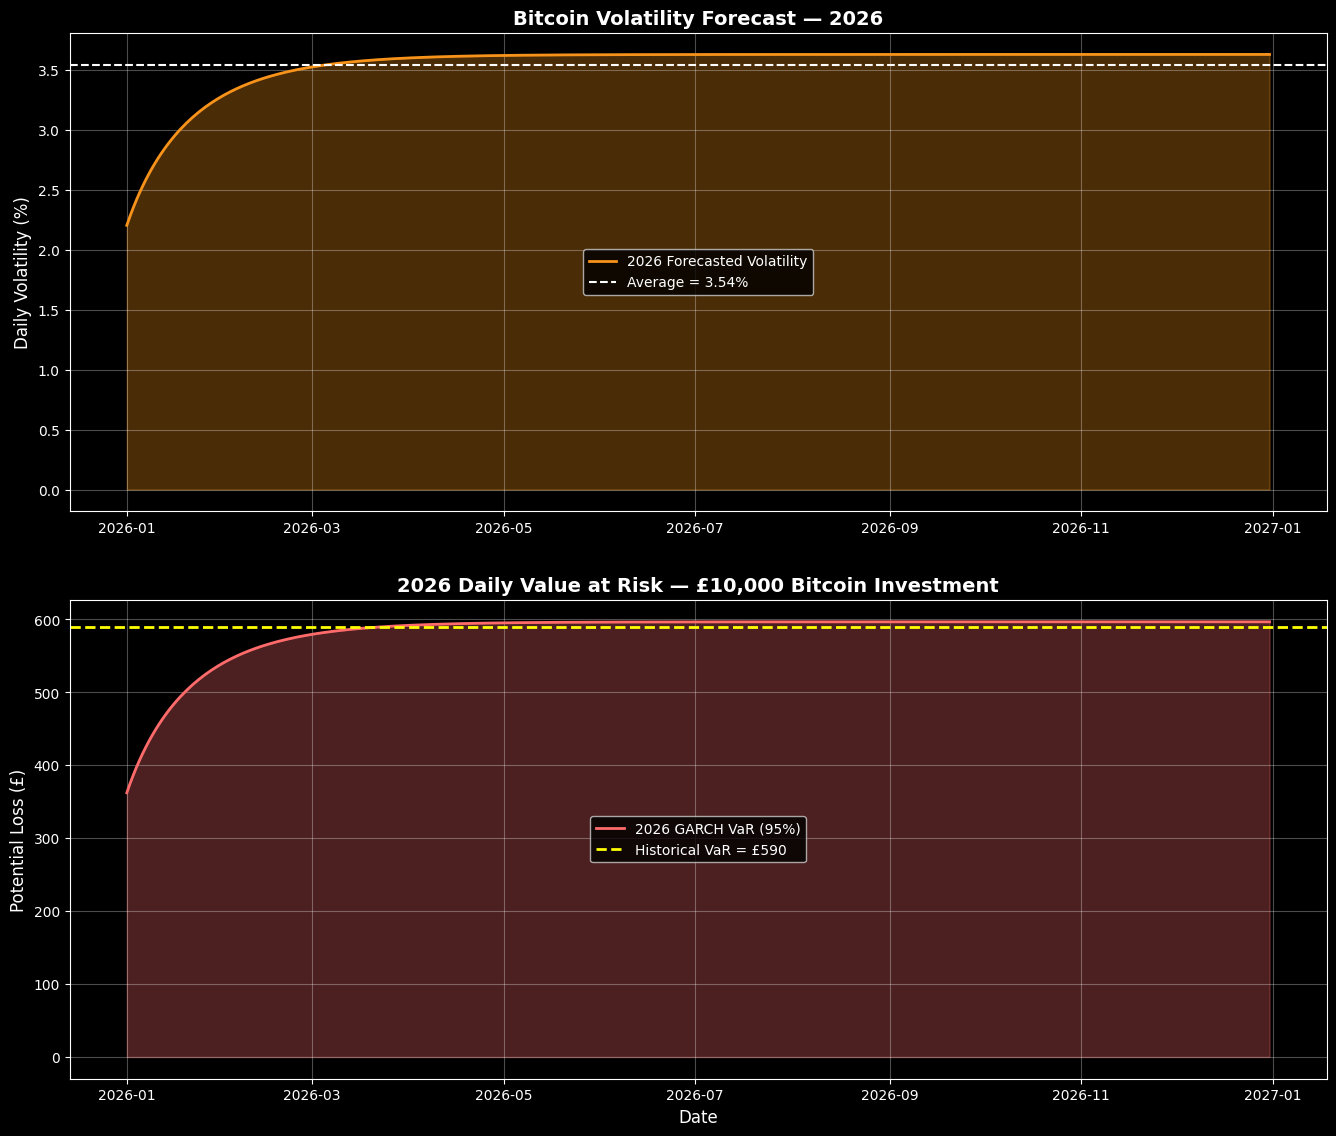

In [18]:
# Cell 17 — Retrain GARCH on 2018-2025 + Forecast 2026

from arch import arch_model

# Step 1: Combine ALL returns (2018-2023 + 2024 + 2025)
all_returns = pd.concat([train_returns, test_returns, returns_2025])

print("=" * 50)
print("📊 Combined Dataset")
print("=" * 50)
print(f"   Training returns  : {len(train_returns)} days (2018-2023)")
print(f"   2024 returns      : {len(test_returns)} days")
print(f"   2025 returns      : {len(returns_2025)} days")
print(f"   Total combined    : {len(all_returns)} days (2018-2025)")
print(f"   From : {all_returns.index[0].date()}")
print(f"   To   : {all_returns.index[-1].date()}")

# Step 2: Retrain GARCH on all data
print("\n⏳ Retraining GARCH on 2018-2025 data...")
garch_model_2026 = arch_model(all_returns * 100, vol='Garch', p=1, q=1, dist='normal')
garch_fit_2026 = garch_model_2026.fit(disp='off')

# Step 3: Compare old vs new parameters
print("\n" + "=" * 50)
print("📊 GARCH Parameters — Old vs New")
print("=" * 50)
print(f"{'Parameter':<15} {'Old (2018-2023)':>18} {'New (2018-2025)':>18}")
print("-" * 52)
print(f"{'omega':<15} {'0.7232':>18} {garch_fit_2026.params['omega']:>18.4f}")
print(f"{'alpha[1]':<15} {'0.0953':>18} {garch_fit_2026.params['alpha[1]']:>18.4f}")
print(f"{'beta[1]':<15} {'0.8566':>18} {garch_fit_2026.params['beta[1]']:>18.4f}")
print(f"{'alpha+beta':<15} {'0.9520':>18} {garch_fit_2026.params['alpha[1]'] + garch_fit_2026.params['beta[1]']:>18.4f}")

# Step 4: Forecast 2026
n_forecast_2026 = 365
garch_forecast_2026 = garch_fit_2026.forecast(horizon=n_forecast_2026, reindex=False)
forecast_variance_2026 = garch_forecast_2026.variance.values[-1]
forecast_volatility_2026 = np.sqrt(forecast_variance_2026) / 100
forecast_dates_2026 = pd.date_range(start='2026-01-01', periods=n_forecast_2026, freq='D')
forecast_var_2026 = z_score * forecast_volatility_2026

# Step 5: Print 2026 summary
print("\n" + "=" * 50)
print("🔮 2026 GARCH Volatility Forecast")
print("=" * 50)
print(f"   Forecast days        : {n_forecast_2026}")
print(f"   Average volatility   : {forecast_volatility_2026.mean():.4f} ({forecast_volatility_2026.mean()*100:.2f}% per day)")
print(f"   Max volatility       : {forecast_volatility_2026.max():.4f} ({forecast_volatility_2026.max()*100:.2f}%)")
print(f"   Min volatility       : {forecast_volatility_2026.min():.4f} ({forecast_volatility_2026.min()*100:.2f}%)")

print(f"\n💰 2026 VaR Estimates (£{investment:,} investment):")
print(f"   Average daily VaR    : £{abs(forecast_var_2026.mean() * investment):,.2f}")
print(f"   Worst day VaR        : £{abs(forecast_var_2026.min() * investment):,.2f}")
print(f"   Best day VaR         : £{abs(forecast_var_2026.max() * investment):,.2f}")

# Step 6: Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1 — Volatility forecast
axes[0].plot(forecast_dates_2026, forecast_volatility_2026 * 100,
             color='#F7931A', linewidth=2, label='2026 Forecasted Volatility')
axes[0].fill_between(forecast_dates_2026, 0, forecast_volatility_2026 * 100,
                     color='#F7931A', alpha=0.3)
axes[0].axhline(y=forecast_volatility_2026.mean() * 100,
                color='white', linewidth=1.5, linestyle='--',
                label=f'Average = {forecast_volatility_2026.mean()*100:.2f}%')
axes[0].set_title('Bitcoin Volatility Forecast — 2026', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Daily Volatility (%)', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2 — VaR forecast in £
axes[1].plot(forecast_dates_2026, abs(forecast_var_2026 * investment),
             color='#FF6B6B', linewidth=2, label='2026 GARCH VaR (95%)')
axes[1].fill_between(forecast_dates_2026, 0, abs(forecast_var_2026 * investment),
                     color='#FF6B6B', alpha=0.3)
axes[1].axhline(y=abs(historical_var * investment),
                color='yellow', linewidth=2, linestyle='--',
                label=f'Historical VaR = £{abs(historical_var * investment):,.0f}')
axes[1].set_title(f'2026 Daily Value at Risk — £{investment:,} Bitcoin Investment',
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('Potential Loss (£)', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout(pad=3.0)
plt.savefig('../data/2026_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:

print("=" * 50)
print("🔮 2026 Full Volatility Summary")
print("=" * 50)
print(f"   Average volatility : {forecast_volatility_2026.mean():.4f} ({forecast_volatility_2026.mean()*100:.2f}% per day)")
print(f"   Max volatility     : {forecast_volatility_2026.max():.4f} ({forecast_volatility_2026.max()*100:.2f}%)")
print(f"   Min volatility     : {forecast_volatility_2026.min():.4f} ({forecast_volatility_2026.min()*100:.2f}%)")


🔮 2026 Full Volatility Summary
   Average volatility : 0.0354 (3.54% per day)
   Max volatility     : 0.0363 (3.63%)
   Min volatility     : 0.0220 (2.20%)
